# Exercises

# 1. What are the main motivations for reducing a dataset’s dimensionality? What are the main drawbacks?

Motivations: Mitigate the curse of dimensionality, improve speed and performance, enable visualization, and reduce storage needs.

Drawbacks: Potential information loss, added preprocessing complexity, less interpretable features, and possibly high computational cost for the reduction itself.

# 2. What is the curse of dimensionality?

The curse of dimensionality is the set of challenges caused by the exponential growth of space with dimensionality. It leads to sparse data, unreliable distances, overfitting, and increased computational demands.

# 3. Once a dataset’s dimensionality has been reduced, is it possible to reverse the operation? If so, how? If not, why?

In general, dimensionality reduction is not perfectly reversible.
You can often obtain an approximate reconstruction of the original data, but some information is lost during the reduction, so you cannot fully recover the original dataset.

# 4. Can PCA be used to reduce the dimensionality of a highly nonlinear dataset?

Standard PCA is not well-suited for highly nonlinear datasets. However, can handle nonlinear structures by first applying a Kernel PCA or by transforming the data into a space where linear methods work better.

# 5. Suppose you perform PCA on a 1,000-dimensional dataset, setting the explained variance ratio to 95%. How many dimensions will the resulting dataset have?

You cannot know the exact number of dimensions in advance.
The number of dimensions after PCA with an explained variance ratio of 95% is determined by the data itself, not fixed beforehand.

# 6. In what cases would you use vanilla PCA, Incremental PCA, Randomized PCA, or Kernel PCA?

Vanilla PCA: Default choice for moderate-size, linear data.

Incremental PCA: For huge datasets or streaming data.

Randomized PCA: For very high-dimensional data when speed matters.

Kernel PCA: For capturing nonlinear relationships.

# 7. How can you evaluate the performance of a dimensionality reduction algorithm on your dataset?

For PCA: Use explained variance ratio and reconstruction error.

For downstream ML tasks: Compare performance before and after reduction.

For nonlinear DR: Assess how well the reduced data preserves local/global structures.

Always balance information retention with practical gains like faster training, reduced overfitting, and better interpretability.

# 8. Does it make any sense to chain two different dimensionality reduction algorithms?

Yes, it can make sense in some cases—but it depends on the purpose.

Chaining dimensionality reduction algorithms can be useful when each method addresses a different aspect of the data’s structure, but it must be done carefully to avoid unnecessary information loss.

# 9. Load the MNIST dataset (introduced in Chapter 3) and split it into a training set and a test set (take the first 60,000 instances for training, and the remaining 10,000 for testing). Train a Random Forest classifier on the dataset and time how long it takes, then evaluate the resulting model on the test set. Next, use PCA to reduce the dataset’s dimensionality, with an explained variance ratio of 95%. Train a new Random Forest classifier on the reduced dataset and see how long it takes. Was training much faster? Next evaluate the classifier on the test set: how does it compare to the previous classifier?

import time
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import time


In [2]:
# Load MNIST from OpenML

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X, y = mnist.data, mnist.target.astype(np.uint8)

# Split into training (first 60,000) and test (last 10,000)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (60000, 784)
Test set shape: (10000, 784)


In [3]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start_time = time.time()
rf_clf.fit(X_train, y_train)
rf_time = time.time() - start_time

y_pred = rf_clf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred)

print(f"Random Forest on original data:")
print(f"  Training time: {rf_time:.2f} seconds")
print(f"  Test accuracy: {rf_acc:.4f}")

Random Forest on original data:
  Training time: 5.71 seconds
  Test accuracy: 0.9705


In [4]:
pca = PCA(n_components=0.95)

# Fit PCA on training data
pca.fit(X_train)

# Transform both training and test sets
X_train_reduced = pca.transform(X_train)
X_test_reduced = pca.transform(X_test)

print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_reduced.shape)

Original shape: (60000, 784)
Reduced shape: (60000, 154)


In [5]:
rf_clf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start_time = time.time()
rf_clf_pca.fit(X_train_reduced, y_train)
rf_pca_time = time.time() - start_time

y_pred_pca = rf_clf_pca.predict(X_test_reduced)
rf_pca_acc = accuracy_score(y_test, y_pred_pca)

print(f"Random Forest on PCA-reduced data:")
print(f"  Training time: {rf_pca_time:.2f} seconds")
print(f"  Test accuracy: {rf_pca_acc:.4f}")

Random Forest on PCA-reduced data:
  Training time: 16.93 seconds
  Test accuracy: 0.9488


# 10. Use t-SNE to reduce the MNIST dataset down to two dimensions and plot the result using Matplotlib. You can use a scatterplot using 10 different colors to represent each image’s target class. Alternatively, you can write colored digits at the location of each instance, or even plot scaled-down versions of the digit images themselves (if you plot all digits, the visualization will be too cluttered, so you should either draw a random sample or plot an instance only if no other instance has already been plotted at a close distance). You should get a nice visualization with well-separated clusters of digits. Try using other dimensionality reduction algorithms such as PCA, LLE, or MDS and compare the resulting visualizations.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, LocallyLinearEmbedding, MDS

In [7]:
# Tenta via OpenML (usa internet). Se não tiver internet, veja a célula alternativa abaixo.
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X, y = mnist.data.astype(np.float32), mnist.target.astype(int)

# Padronização ajuda t-SNE/LLE/MDS
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(X.shape, y.shape)  # (70000, 784) (70000,)

(70000, 784) (70000,)


In [8]:
rng = 42
n_tsne = 10000      # bom equilíbrio para t-SNE
n_others = 3000     # LLE/MDS são mais pesados

def stratified_sample(X, y, n, random_state=42):
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=n, random_state=random_state)
    idx, _ = next(splitter.split(X, y))
    return X[idx], y[idx]

X_tsne, y_tsne = stratified_sample(X, y, n_tsne, rng)
X_small, y_small = stratified_sample(X, y, n_others, rng)

X_tsne.shape, X_small.shape

((10000, 784), (3000, 784))

In [9]:
def scatter_2d(Z, labels, title):
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(Z[:, 0], Z[:, 1], c=labels, s=5, cmap="tab10", alpha=0.9)
    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.legend(*sc.legend_elements(num=10), title="Digit", loc="best", frameon=False)
    plt.tight_layout()
    plt.show()

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.006s...
[t-SNE] Computed neighbors for 10000 samples in 4.193s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 5.739225
[t-SNE] KL divergence after 250 iterations with early exaggeration: 89.017921
[t-SNE] KL divergence after 1000 iterations: 1.748962


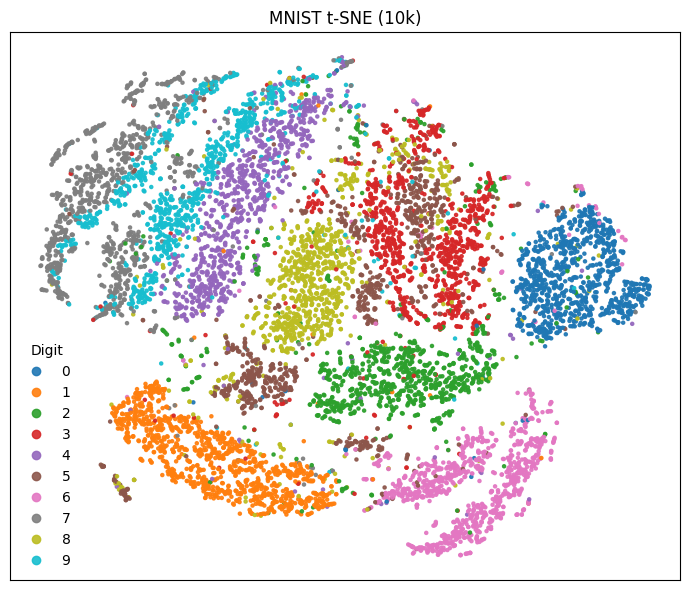

In [10]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    init="pca",
    random_state=42,
    verbose=1
)

Z_tsne = tsne.fit_transform(X_tsne)
scatter_2d(Z_tsne, y_tsne, "MNIST t-SNE (10k)")

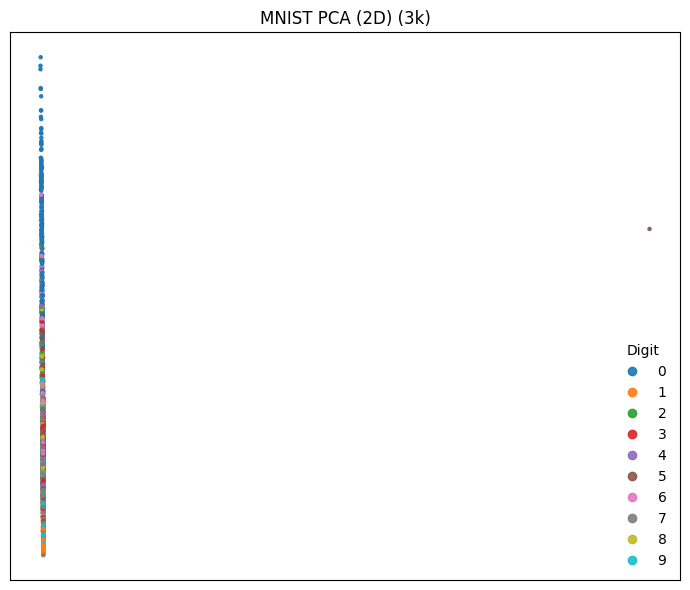

In [11]:
pca_2d = PCA(n_components=2, random_state=42)
Z_pca = pca_2d.fit_transform(X_small)
scatter_2d(Z_pca, y_small, "MNIST PCA (2D) (3k)")

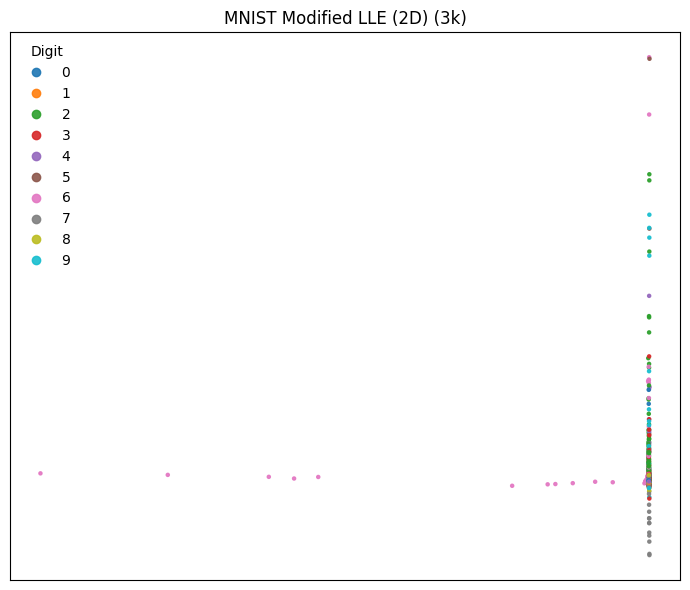

In [12]:
lle = LocallyLinearEmbedding(
    n_neighbors=30,
    n_components=2,
    method="modified",
    random_state=42
)
Z_lle = lle.fit_transform(X_small)
scatter_2d(Z_lle, y_small, "MNIST Modified LLE (2D) (3k)")

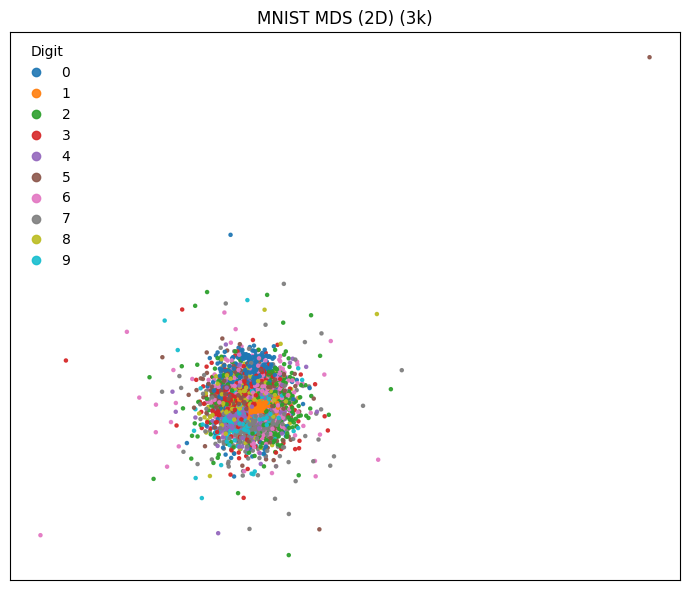

In [13]:
mds = MDS(
    n_components=2,
    n_init=1,
    max_iter=300,
    random_state=42,
    normalized_stress="auto"  # disponível em versões recentes do sklearn
)
Z_mds = mds.fit_transform(X_small)
scatter_2d(Z_mds, y_small, "MNIST MDS (2D) (3k)")